In [8]:
import pandas as pd

data = pd.read_csv("data.csv", delimiter="\t")
monthly_report = data.drop(columns=["Unnamed: 0"])

#calculate and print sample_size:
sample_size = len(monthly_report)
print(sample_size)

#calculate and print num_purchased:
num_purchased = len(monthly_report[monthly_report.purchase == "y"])
print(num_purchased)

500
41


342
233
173
241


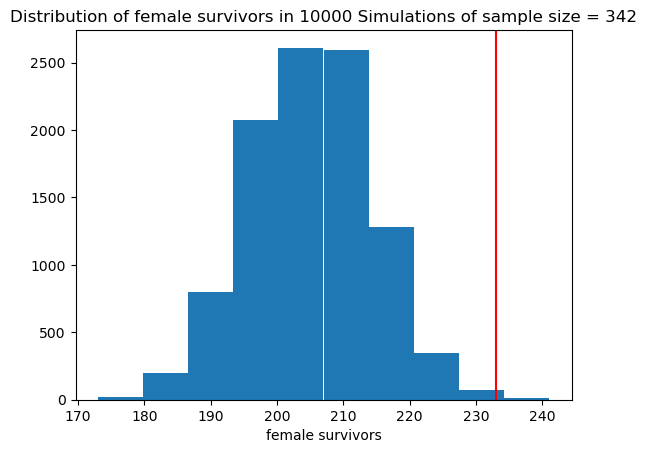

233.00000000000003
[187. 223.]
pvalue= 0.0023


In [92]:
import numpy as np
titanic = pd.read_csv("titanic.csv")

sample_size = len(titanic)
num_successes = len(titanic[titanic.Survived == 1])
# print(sample_size)
# print(num_successes)

sample_size = len(titanic)
num_successes = len(titanic[titanic.Sex == "female"])
# print(sample_size)
# print(num_successes)

survivors = titanic[titanic.Survived == 1]
sample_size = len(survivors)
num_successes = len(survivors[survivors.Sex == "female"])
print(sample_size)
print(num_successes)

null_outcomes = []
for s in range(10000):
  simulated_survivor_female = np.random.choice([1,0], size=342, p=[0.60, 0.40])
  total = np.sum(simulated_survivor_female)
  null_outcomes.append(total)

#calculate the minimum and maximum values in null_outcomes here:
null_min = min(null_outcomes)
null_max = max(null_outcomes)
print(null_min)
print(null_max)

import matplotlib.pyplot as plt
plt.hist(null_outcomes)
plt.axvline(342*(233/342), color = 'r')
plt.xlabel("female survivors")
plt.title("Distribution of female survivors in 10000 Simulations of sample size = 342")
plt.show()

print(233/342*342)

confidence_int = np.percentile(null_outcomes, [2.5,97.5])
print(confidence_int)

values = sum((x >= 233) or (x <= 177) for x in null_outcomes)
p_value_two_sided = values / len(null_outcomes)
print("pvalue=", p_value_two_sided)


0.2001


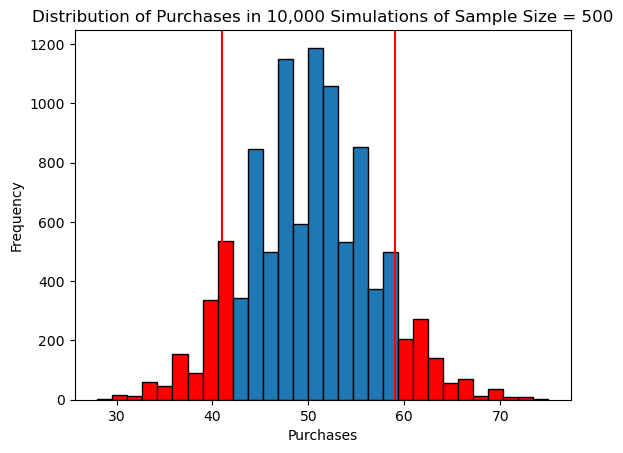

In [88]:

# flip = np.random.choice(['heads', 'tails'], size=10, p=[0.5, 0.5])
# print(flip) 
# ## output is either ['heads'] or ['tails']

# one_visitor = np.random.choice(['y', 'n'], size=1, p=[.1, 1 - .1])
# print(one_visitor)

# simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[.1, 1 - .1])
# print(sum(simulated_monthly_visitors == "y"))
# simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[.1, 1 - .1])
# print(sum(simulated_monthly_visitors == "y"))
# simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[.1, 1 - .1])
# print(sum(simulated_monthly_visitors == "y"))
# simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[.1, 1 - .1])
# print(sum(simulated_monthly_visitors == "y"))
# simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[.1, 1 - .1])
# print(sum(simulated_monthly_visitors == "y"))


null_outcomes = []
for s in range(10000):
    simulated_monthly_visitors = np.random.choice(['y', 'n'], size=500, p=[0.1, 0.9])
    num_purchased = np.sum(simulated_monthly_visitors == 'y')
    null_outcomes.append(num_purchased)

values = sum((x <= 41) or (x >= 59) for x in null_outcomes)
p_value_two_sided = values / len(null_outcomes)
print(p_value_two_sided)

counts, bins, patches = plt.hist(null_outcomes, bins=30, edgecolor="black")

for i in range(len(patches)):
    if bins[i] < 41:
        patches[i].set_facecolor("red")

for i in range(len(patches)):
    if bins[i] >= 58:
        patches[i].set_facecolor("red")

plt.axvline(41, color='r')
plt.axvline(59, color='r')
plt.xlabel("Purchases")
plt.ylabel("Frequency")
plt.title("Distribution of Purchases in 10,000 Simulations of Sample Size = 500")
plt.show()


In [ ]:
def simulation_binomial_test(observed_successes, n, p):
  #initialize null_outcomes
  null_outcomes = []
  
  #generate the simulated null distribution
  for i in range(10000):
    simulated_monthly_visitors = np.random.choice(['y', 'n'], size=n, p=[p, 1-p])
    num_purchased = np.sum(simulated_monthly_visitors == 'y')
    null_outcomes.append(num_purchased)

  #calculate a 1-sided p-value
  null_outcomes = np.array(null_outcomes)
  p_value = np.sum(null_outcomes <= observed_successes)/len(null_outcomes) 
  
  #return the p-value
  return p_value

p_value = simulation_binomial_test(41, 500, .10)
print(p_value)